<a href="https://colab.research.google.com/github/Sibitenda/Diploma/blob/main/wek6_curve_notebook_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Geometric Modeling - Curve Representation Notebook

This notebook demonstrates key concepts:
- Parametric vs Non-parametric curves
- Interpolation vs Approximation
- Hermite Curves
- Bézier Curves
- B-Spline Curves

## Real Project Section
- Image → Curve modeling


## 1. Explicit Curves
**Concept:** y = f(x)

**Expectation (2D):** A curve in a plane
**Limitation:** Cannot represent complex or vertical shapes
**3D Extension:** Produces a surface z = f(x,y)

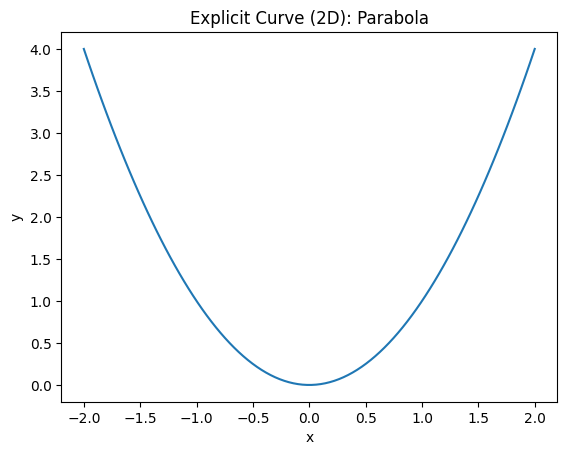

In [1]:

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2,2,100)
y = x**2

plt.plot(x,y)
plt.title("Explicit Curve (2D): Parabola")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


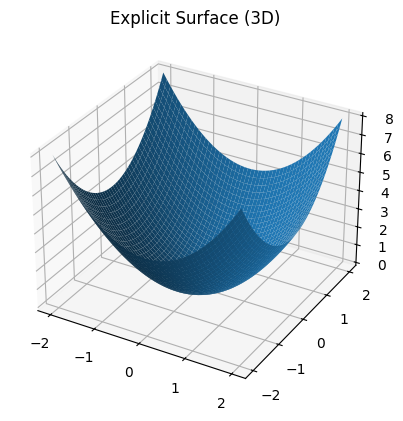

In [2]:

# 3D surface from explicit form
from mpl_toolkits.mplot3d import Axes3D

X = np.linspace(-2,2,50)
Y = np.linspace(-2,2,50)
X, Y = np.meshgrid(X,Y)
Z = X**2 + Y**2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,Z)
ax.set_title("Explicit Surface (3D)")
plt.show()


## 2. Parametric Curves
**Concept:** x=f(t), y=g(t)

**Expectation:** Flexible shapes (circles, spirals)
**3D:** Curves in space

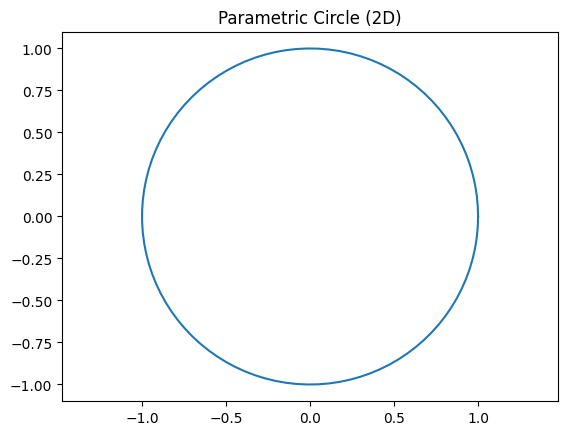

In [3]:

t = np.linspace(0,2*np.pi,100)
x = np.cos(t)
y = np.sin(t)

plt.plot(x,y)
plt.title("Parametric Circle (2D)")
plt.axis('equal')
plt.show()


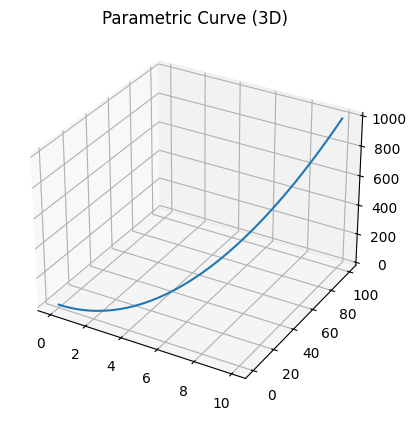

In [13]:

t = np.linspace(0,10,100)
x = t
y = t**2
z = t**3

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x,y,z)
ax.set_title("Parametric Curve (3D)")
plt.show()


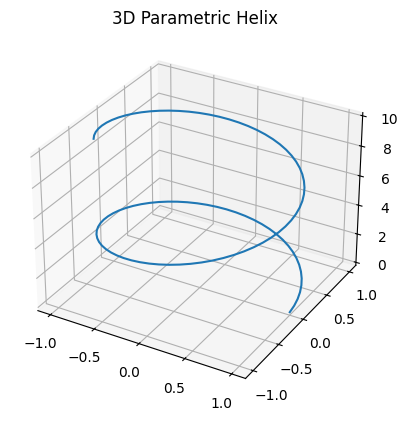

In [14]:

# 3D parametric helix
t = np.linspace(0,10,100)
x = np.cos(t)
y = np.sin(t)
z = t

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x,y,z)
ax.set_title("3D Parametric Helix")
plt.show()


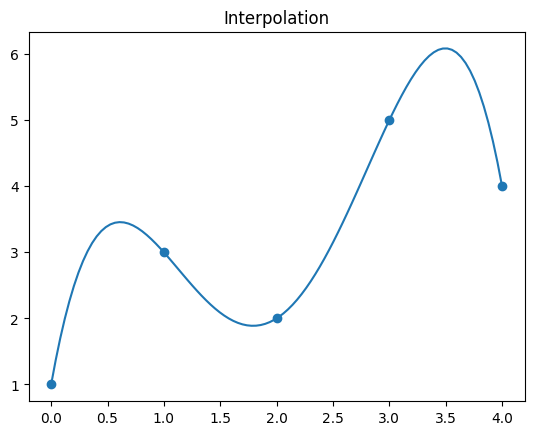

In [11]:

x = np.array([0,1,2,3,4])
y = np.array([1,3,2,5,4])

coeff = np.polyfit(x,y,4)
poly = np.poly1d(coeff)

x_new = np.linspace(0,4,100)

plt.scatter(x,y)
plt.plot(x_new,poly(x_new))
plt.title("Interpolation")
plt.show()


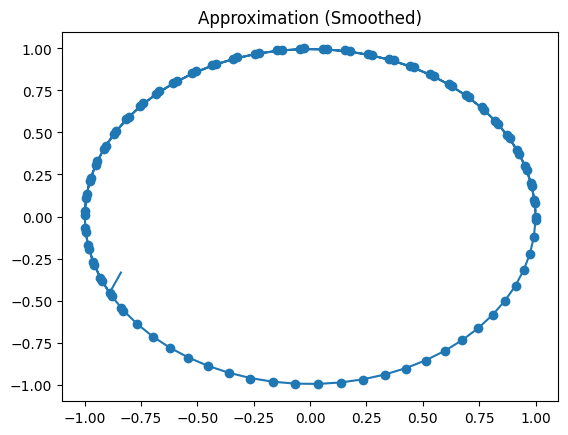

In [15]:

# Approximation using smoothing (simple moving average)
y_smooth = np.convolve(y, np.ones(3)/3, mode='same')

plt.scatter(x,y)
plt.plot(x,y_smooth)
plt.title("Approximation (Smoothed)")
plt.show()


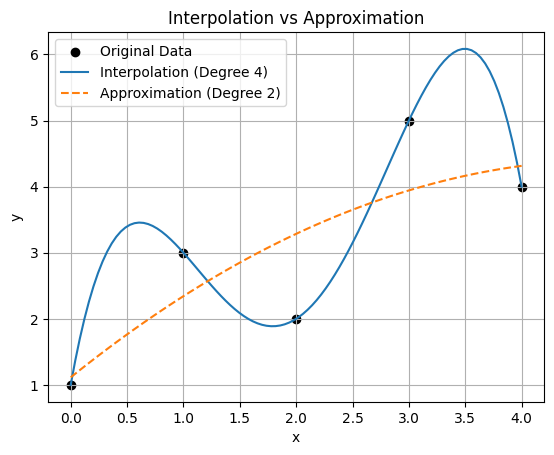

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Original data
x = np.array([0,1,2,3,4])
y = np.array([1,3,2,5,4])

# INTERPOLATION (passes through ALL points)

coeff_interp = np.polyfit(x, y, 4)   # degree = n-1 → exact fit
poly_interp = np.poly1d(coeff_interp)


# APPROXIMATION (smooth fit, does NOT pass all points)

coeff_approx = np.polyfit(x, y, 2)   # lower degree → approximation
poly_approx = np.poly1d(coeff_approx)

# Generate smooth x values
x_new = np.linspace(0, 4, 100)


plt.scatter(x, y, color='black', label='Original Data')

plt.plot(x_new, poly_interp(x_new), label='Interpolation (Degree 4)')
plt.plot(x_new, poly_approx(x_new), linestyle='--', label='Approximation (Degree 2)')

plt.title("Interpolation vs Approximation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

## 3. Hermite Curves
**Concept:** Defined by endpoints + tangents
**Expectation:** Shape controlled by slopes

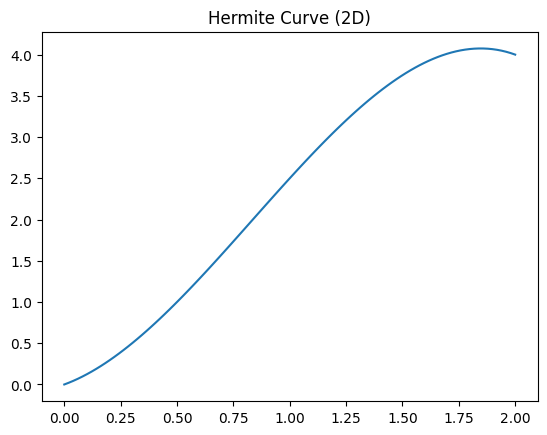

In [8]:

def hermite(p0,p1,t0,t1,t):
    h1 = 2*t**3 - 3*t**2 + 1
    h2 = -2*t**3 + 3*t**2
    h3 = t**3 - 2*t**2 + t
    h4 = t**3 - t**2
    return h1*p0 + h2*p1 + h3*t0 + h4*t1

t = np.linspace(0,1,100)
p0 = np.array([0,0])
p1 = np.array([2,4])
t0 = np.array([2,2])
t1 = np.array([2,-2])

curve = np.array([hermite(p0,p1,t0,t1,ti) for ti in t])

plt.plot(curve[:,0],curve[:,1])
plt.title("Hermite Curve (2D)")
plt.show()


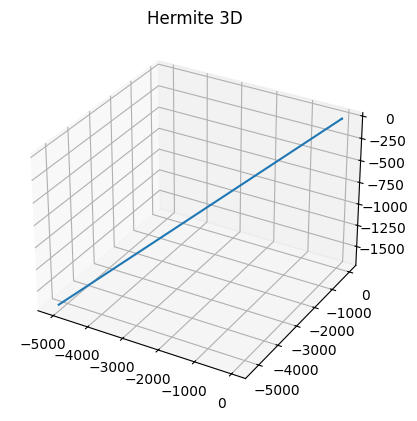

In [16]:

# 3D Hermite
p0 = np.array([0,0,0])
p1 = np.array([5,3,2])
t0 = np.array([2,2,1])
t1 = np.array([2,-2,1])

curve3d = np.array([hermite(p0,p1,t0,t1,ti) for ti in t])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(curve3d[:,0],curve3d[:,1],curve3d[:,2])
ax.set_title("Hermite 3D")
plt.show()


## 4. Bézier Curves
**Concept:** Controlled by control points
**Expectation:** Smooth curve influenced globally

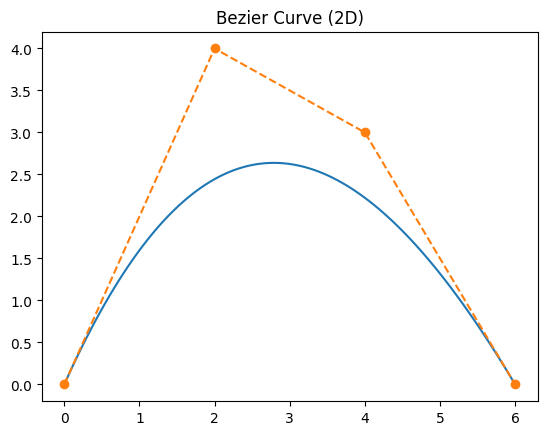

In [6]:

def bezier(points,t):
    points = np.array(points)
    for r in range(1,len(points)):
        points = (1-t)*points[:-1] + t*points[1:]
    return points[0]

control = np.array([[0,0],[2,4],[4,3],[6,0]])
t_vals = np.linspace(0,1,100)
curve = np.array([bezier(control,t) for t in t_vals])

plt.plot(curve[:,0],curve[:,1])
plt.plot(control[:,0],control[:,1],'--o')
plt.title("Bezier Curve (2D)")
plt.show()


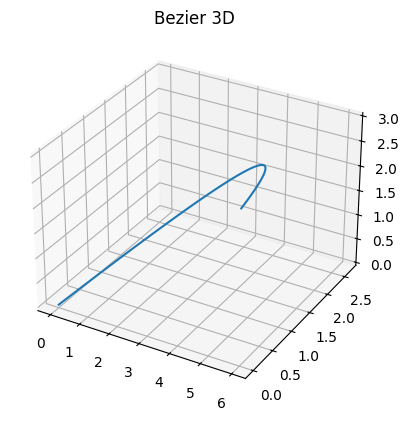

In [18]:

# 3D Bezier
control3d = np.array([[0,0,0],[2,4,1],[4,3,2],[6,0,3]])
curve3d = np.array([bezier(control3d,t) for t in t_vals])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(curve3d[:,0],curve3d[:,1],curve3d[:,2])
ax.set_title("Bezier 3D")
plt.show()


## 5. B-Spline Curves
**Concept:** Local control, smoother
**Expectation:** Stable curves for real data

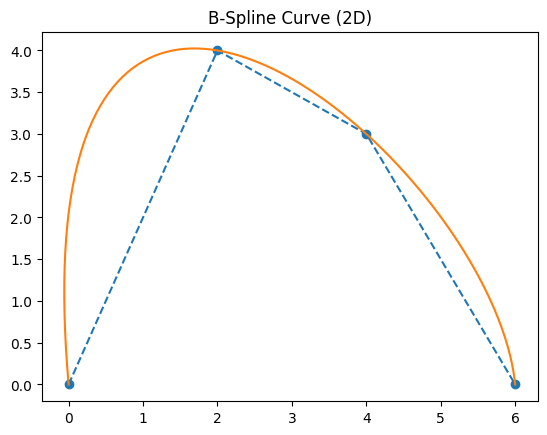

In [9]:

from scipy.interpolate import splprep, splev

points = np.array([[0,0],[2,4],[4,3],[6,0]])

tck,u = splprep([points[:,0],points[:,1]],s=0)
new = splev(np.linspace(0,1,100),tck)

plt.plot(points[:,0],points[:,1],'o--')
plt.plot(new[0],new[1])
plt.title("B-Spline Curve (2D)")
plt.show()


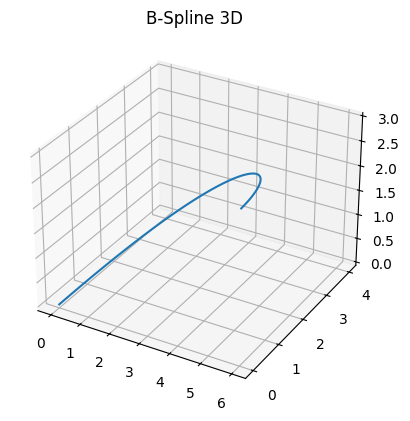

In [19]:

# 3D B-spline
points3d = np.array([[0,0,0],[2,4,1],[4,3,2],[6,0,3]])
tck,u = splprep([points3d[:,0],points3d[:,1],points3d[:,2]],s=0)
new3d = splev(np.linspace(0,1,100),tck)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(new3d[0],new3d[1],new3d[2])
ax.set_title("B-Spline 3D")
plt.show()


In [21]:
!pip install opencv-python



### Dataset: Handwritten Digits (from sklearn)

This notebook uses a real dataset (digit images) to:
- Extract shape coordinates
- Apply analytical and synthetic curves
- Compare curve modeling techniques


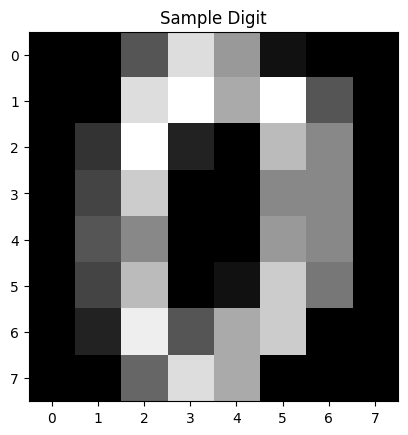

In [23]:

from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt

digits = load_digits()
image = digits.images[0]

plt.imshow(image, cmap='gray')
plt.title("Sample Digit")
plt.show()


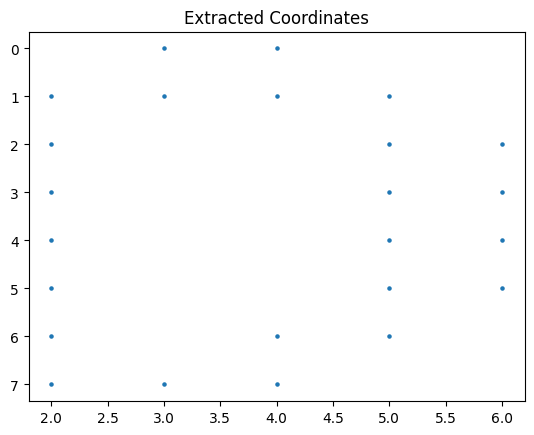

In [24]:
#Convert Image to Coordinate Points
points = np.column_stack(np.where(image > 5))

plt.scatter(points[:,1], points[:,0], s=5)
plt.gca().invert_yaxis()
plt.title("Extracted Coordinates")
plt.show()


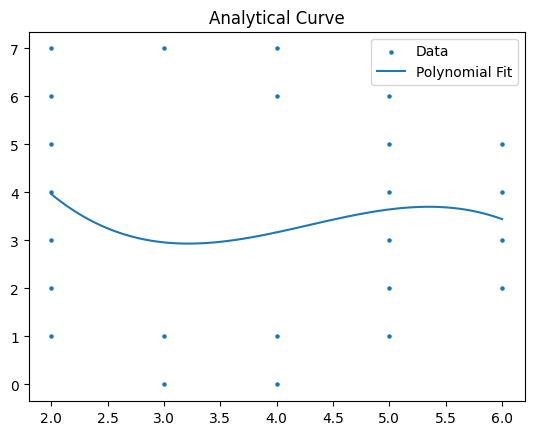

In [26]:
# Analytical Curve (Polynomial Approximation)
x = points[:,1]
y = points[:,0]

coeff = np.polyfit(x, y, 3)
poly = np.poly1d(coeff)

x_new = np.linspace(x.min(), x.max(), 100)

plt.scatter(x,y,s=5,label="Data")
plt.plot(x_new, poly(x_new), label="Polynomial Fit")
plt.legend()
plt.title("Analytical Curve")
plt.show()


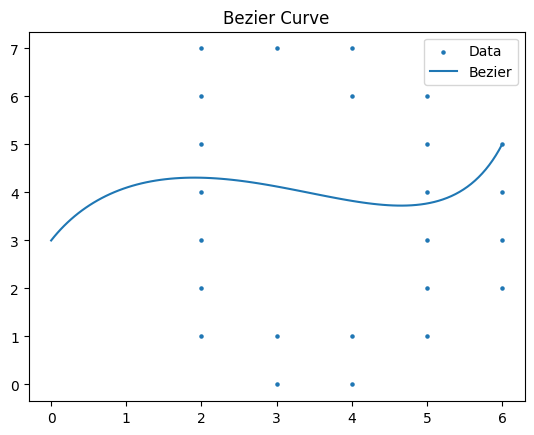

In [28]:
# Synthetic Curve: Bézier

def bezier(points,t):
    points = np.array(points)
    for r in range(1,len(points)):
        points = (1-t)*points[:-1] + t*points[1:]
    return points[0]

control = points[::5]

t_vals = np.linspace(0,1,100)
curve = np.array([bezier(control,t) for t in t_vals])

plt.scatter(x,y,s=5,label="Data")
plt.plot(curve[:,0],curve[:,1],label="Bezier")
plt.legend()
plt.title("Bezier Curve")
plt.show()


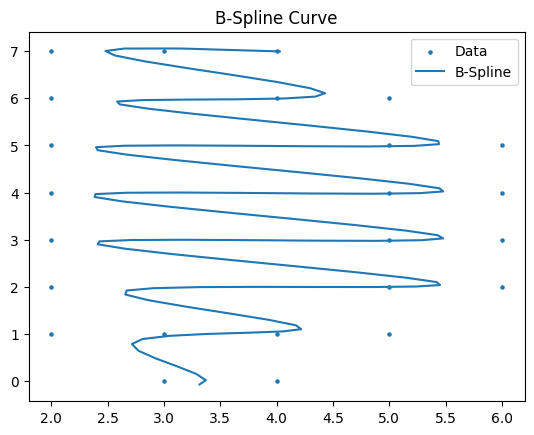

In [29]:
# Synthetic Curve: B-Spline

from scipy.interpolate import splprep, splev

tck,u = splprep([x,y],s=5)
new = splev(np.linspace(0,1,100),tck)

plt.scatter(x,y,s=5,label="Data")
plt.plot(new[0],new[1],label="B-Spline")
plt.legend()
plt.title("B-Spline Curve")
plt.show()


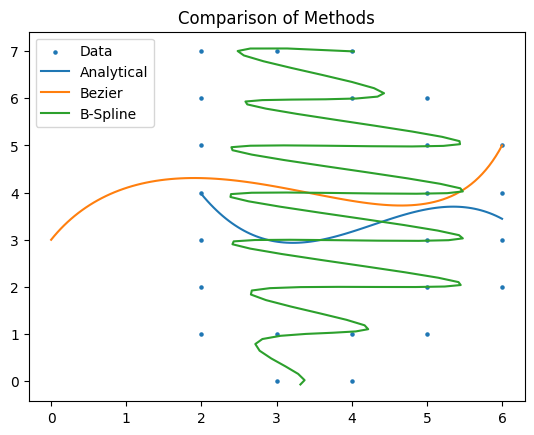

In [30]:
# Compariison

plt.scatter(x,y,s=5,label="Data")
plt.plot(x_new, poly(x_new), label="Analytical")
plt.plot(curve[:,0],curve[:,1], label="Bezier")
plt.plot(new[0],new[1], label="B-Spline")

plt.legend()
plt.title("Comparison of Methods")
plt.show()



## Part A: Data Loading & Preprocessing (Real Dataset)

**Tasks**
- Load dataset from URL
- Assign column names
- Extract latitude/longitude
- Clean missing/invalid values
- Normalize coordinates for curve modeling


In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load OpenFlights airports dataset
url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
cols = ["AirportID","Name","City","Country","IATA","ICAO","Latitude","Longitude","Altitude","Timezone","DST","Tz","Type","Source"]
df = pd.read_csv(url, header=None, names=cols)

# Keep only valid lat/lon
df = df.dropna(subset=["Latitude","Longitude"])

# Extract arrays
lat = df["Latitude"].astype(float).values
lon = df["Longitude"].astype(float).values

# Sample a subset for visualization/performance
idx = np.linspace(0, len(lat)-1, 500, dtype=int)
lat_s = lat[idx]
lon_s = lon[idx]

# Normalize to [0,1] for stable curve fitting
x = (lon_s - lon_s.min()) / (lon_s.max() - lon_s.min())
y = (lat_s - lat_s.min()) / (lat_s.max() - lat_s.min())

# Create a synthetic altitude for 3D (e.g., slight variation)
z = 0.1*np.sin(4*np.pi*x) + 0.1*np.cos(4*np.pi*y)

print("Loaded points:", len(x))


Loaded points: 500


In [34]:
df.shape

(7698, 14)


## Exploratory Data Analysis (EDA)

- Plot spatial distribution (2D)
- Inspect spread and patterns
- Create a simple ordered path (sort by longitude) to emulate a trajectory


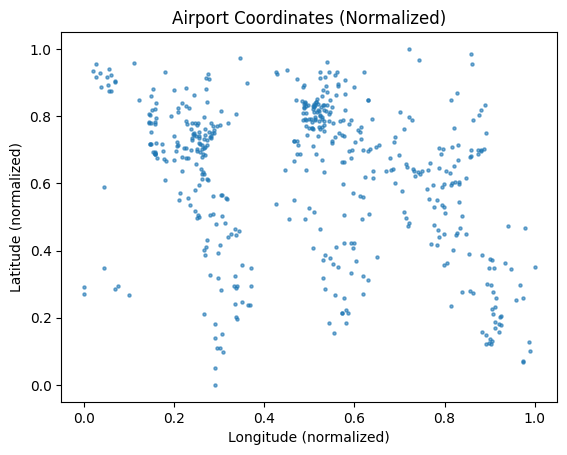

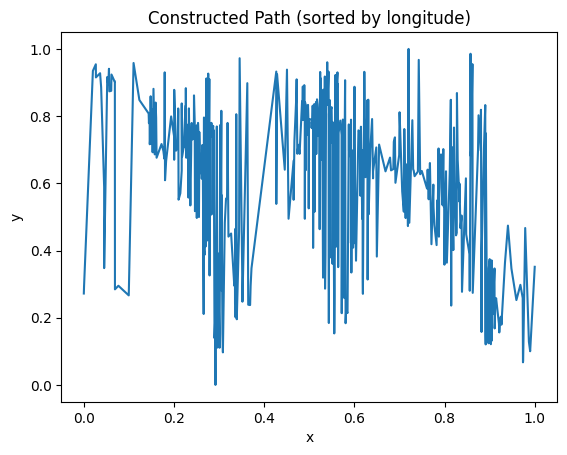

In [35]:

# 2D scatter of airports
plt.figure()
plt.scatter(x, y, s=5, alpha=0.6)
plt.title("Airport Coordinates (Normalized)")
plt.xlabel("Longitude (normalized)")
plt.ylabel("Latitude (normalized)")
plt.show()

# Create a simple path by sorting by x (longitude)
order = np.argsort(x)
x_path = x[order]
y_path = y[order]
z_path = z[order]

plt.figure()
plt.plot(x_path, y_path, '-')
plt.title("Constructed Path (sorted by longitude)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



## Section 1: Analytical Curves (Explicit)

**Concept:** y = f(x)

### 2D Example
- Fit a polynomial to the path (interpolation/approximation)

### 3D Example
- z = f(x, y) → surface (explicit form yields surfaces in 3D)


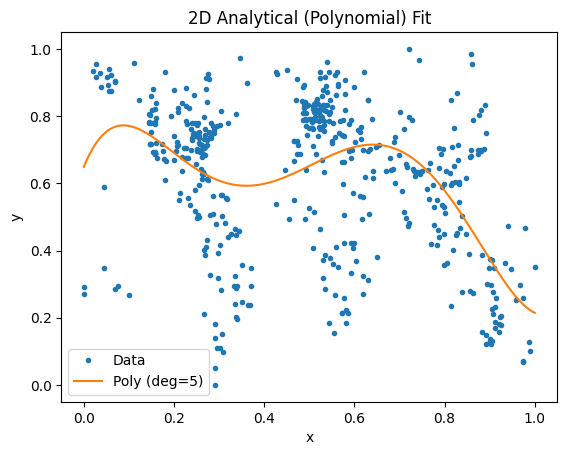

In [36]:

# 2D Analytical: Polynomial approximation
coeff = np.polyfit(x_path, y_path, 5)
poly = np.poly1d(coeff)

x_new = np.linspace(x_path.min(), x_path.max(), 400)

plt.figure()
plt.plot(x_path, y_path, '.', label="Data")
plt.plot(x_new, poly(x_new), '-', label="Poly (deg=5)")
plt.legend()
plt.title("2D Analytical (Polynomial) Fit")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


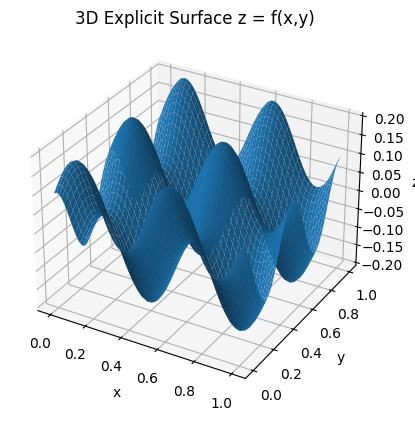

In [37]:

# 3D Analytical: z = f(x,y) surface (illustrative)
from mpl_toolkits.mplot3d import Axes3D

# Create grid
gx = np.linspace(0,1,50)
gy = np.linspace(0,1,50)
GX, GY = np.meshgrid(gx, gy)
GZ = 0.1*np.sin(4*np.pi*GX) + 0.1*np.cos(4*np.pi*GY)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(GX, GY, GZ)
ax.set_title("3D Explicit Surface z = f(x,y)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.show()



## Section 2: Parametric Curves

**Concept:** x = f(t), y = g(t), z = h(t)

### 2D Example
- Use parameter t to trace a smoothed path

### 3D Example
- Extend to (x(t), y(t), z(t)) for spatial curves


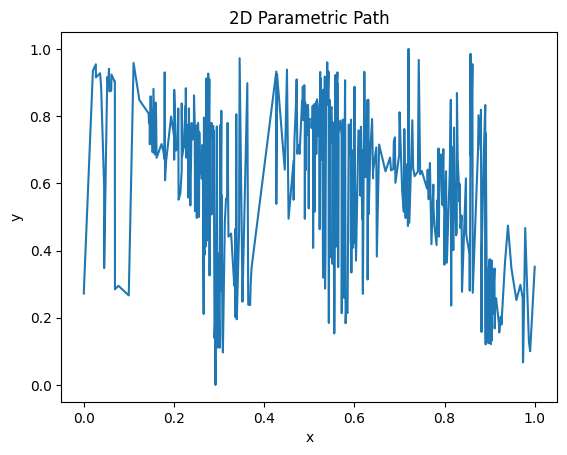

In [38]:

# 2D Parametric (using index parameter)
t = np.linspace(0, 1, len(x_path))
plt.figure()
plt.plot(x_path, y_path)
plt.title("2D Parametric Path")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


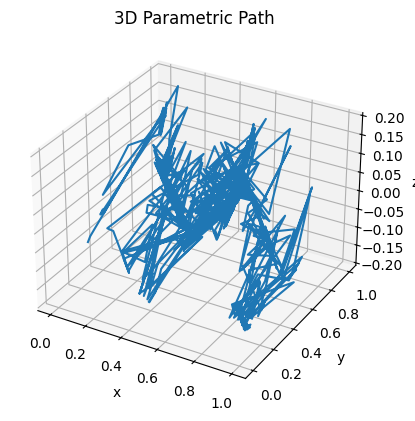

In [39]:

# 3D Parametric curve
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_path, y_path, z_path)
ax.set_title("3D Parametric Path")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.show()



## Section 3: Interpolation vs Approximation

- **Interpolation:** passes through all points (high-degree polynomial)
- **Approximation:** smooth trend (lower-degree polynomial)


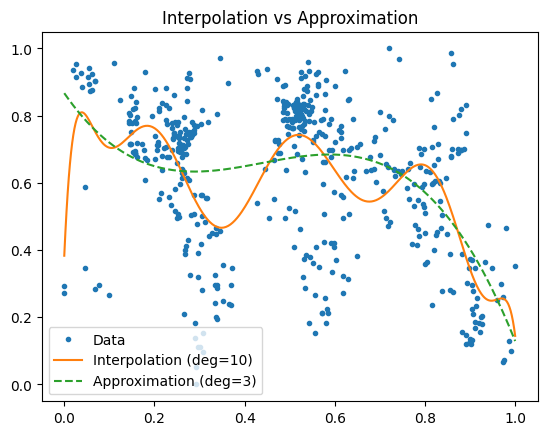

In [40]:

# Interpolation (high degree)
deg = min(10, len(x_path)-1)
poly_interp = np.poly1d(np.polyfit(x_path, y_path, deg))

# Approximation (lower degree)
poly_approx = np.poly1d(np.polyfit(x_path, y_path, 3))

x_new = np.linspace(x_path.min(), x_path.max(), 400)

plt.figure()
plt.plot(x_path, y_path, '.', label="Data")
plt.plot(x_new, poly_interp(x_new), label=f"Interpolation (deg={deg})")
plt.plot(x_new, poly_approx(x_new), '--', label="Approximation (deg=3)")
plt.legend()
plt.title("Interpolation vs Approximation")
plt.show()



## Section 4: Hermite Curves

**Concept:** Defined by endpoints and tangents.


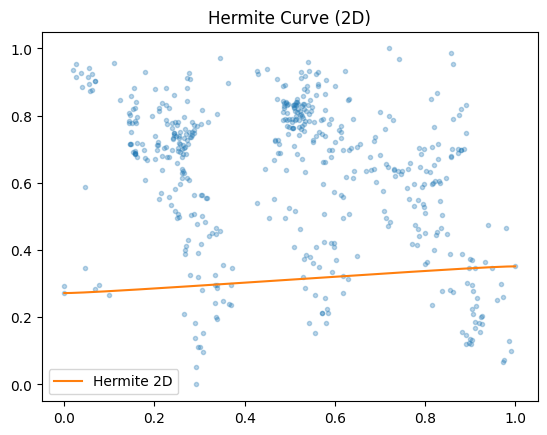

In [41]:

def hermite(p0, p1, t0, t1, t):
    h1 = 2*t**3 - 3*t**2 + 1
    h2 = -2*t**3 + 3*t**2
    h3 = t**3 - 2*t**2 + t
    h4 = t**3 - t**2
    return h1*p0 + h2*p1 + h3*t0 + h4*t1

# Choose endpoints from path
p0 = np.array([x_path[0], y_path[0]])
p1 = np.array([x_path[-1], y_path[-1]])
t0 = np.array([0.3, 0.0])
t1 = np.array([0.3, 0.0])

tt = np.linspace(0,1,200)
curve2d = np.array([hermite(p0, p1, t0, t1, ti) for ti in tt])

plt.figure()
plt.plot(x_path, y_path, '.', alpha=0.3)
plt.plot(curve2d[:,0], curve2d[:,1], label="Hermite 2D")
plt.legend()
plt.title("Hermite Curve (2D)")
plt.show()


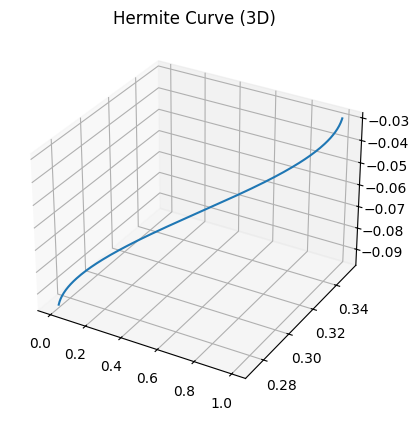

In [42]:

# 3D Hermite
p0_3 = np.array([x_path[0], y_path[0], z_path[0]])
p1_3 = np.array([x_path[-1], y_path[-1], z_path[-1]])
t0_3 = np.array([0.3, 0.0, 0.1])
t1_3 = np.array([0.3, 0.0, 0.1])

curve3d = np.array([hermite(p0_3, p1_3, t0_3, t1_3, ti) for ti in tt])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(curve3d[:,0], curve3d[:,1], curve3d[:,2])
ax.set_title("Hermite Curve (3D)")
plt.show()



## Section 5: Bézier Curves

**Concept:** Control points define curve; global control.


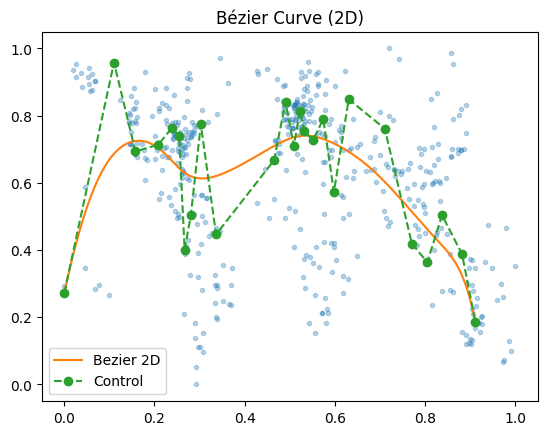

In [43]:

def bezier(points, t):
    points = np.array(points)
    for r in range(1, len(points)):
        points = (1-t)*points[:-1] + t*points[1:]
    return points[0]

control = np.column_stack((x_path[::20], y_path[::20]))
t_vals = np.linspace(0,1,300)
curve_b = np.array([bezier(control, t) for t in t_vals])

plt.figure()
plt.plot(x_path, y_path, '.', alpha=0.3)
plt.plot(curve_b[:,0], curve_b[:,1], label="Bezier 2D")
plt.plot(control[:,0], control[:,1], '--o', label="Control")
plt.legend()
plt.title("Bézier Curve (2D)")
plt.show()


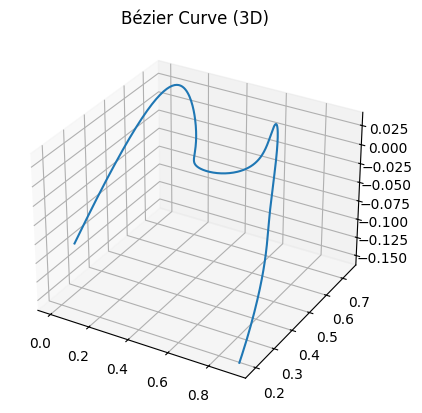

In [44]:

# 3D Bezier
control3 = np.column_stack((x_path[::20], y_path[::20], z_path[::20]))
curve_b3 = np.array([bezier(control3, t) for t in t_vals])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(curve_b3[:,0], curve_b3[:,1], curve_b3[:,2])
ax.set_title("Bézier Curve (3D)")
plt.show()



## Section 6: B-Spline Curves

**Concept:** Piecewise polynomials with local control; ideal for noisy real data.


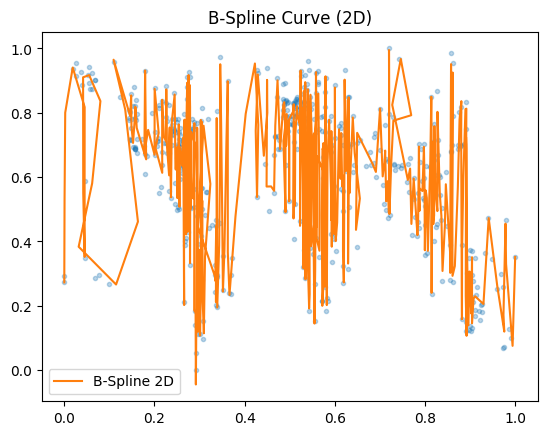

In [45]:

from scipy.interpolate import splprep, splev

tck, u = splprep([x_path, y_path], s=0.01)
new2d = splev(np.linspace(0,1,400), tck)

plt.figure()
plt.plot(x_path, y_path, '.', alpha=0.3)
plt.plot(new2d[0], new2d[1], label="B-Spline 2D")
plt.legend()
plt.title("B-Spline Curve (2D)")
plt.show()


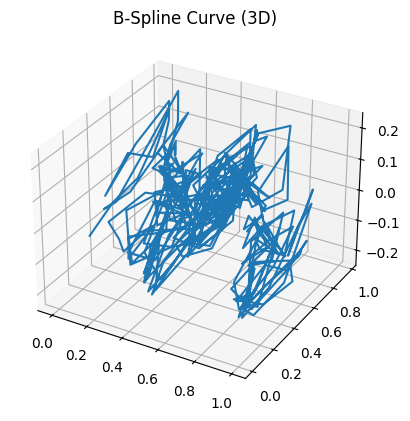

In [46]:

# 3D B-Spline
tck3, u3 = splprep([x_path, y_path, z_path], s=0.01)
new3d = splev(np.linspace(0,1,400), tck3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(new3d[0], new3d[1], new3d[2])
ax.set_title("B-Spline Curve (3D)")
plt.show()



## Section 7: Comparison & Evaluation

Compare analytical vs synthetic methods on the same dataset.


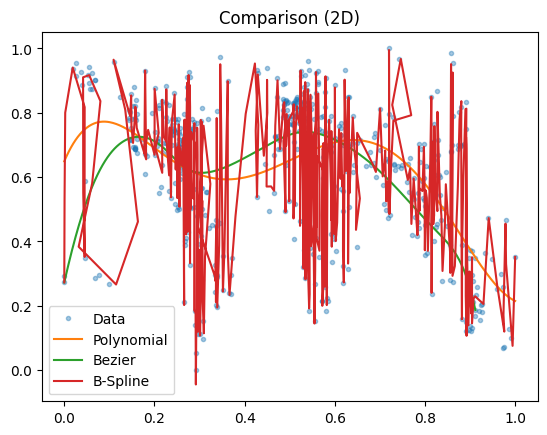

In [47]:

plt.figure()
plt.plot(x_path, y_path, '.', label="Data", alpha=0.4)
plt.plot(x_new, poly(x_new), label="Polynomial")
plt.plot(curve_b[:,0], curve_b[:,1], label="Bezier")
plt.plot(new2d[0], new2d[1], label="B-Spline")
plt.legend()
plt.title("Comparison (2D)")
plt.show()
